In [1]:
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv("data/00-raw/inflation_CPI.csv")

df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,Year,Jan,Feb,Mar,Apr,May,June,July,Aug,Sep,Oct,Nov,Dec
1,1913,9.8,9.8,9.8,9.8,9.7,9.8,9.9,9.9,10,10,10.1,10
2,1914,10,9.9,9.9,9.8,9.9,9.9,10,10.2,10.2,10.1,10.2,10.1
3,1915,10.1,10,9.9,10,10.1,10.1,10.1,10.1,10.1,10.2,10.3,10.3
4,1916,10.4,10.4,10.5,10.6,10.7,10.8,10.8,10.9,11.1,11.3,11.5,11.6


In [3]:
df.columns = df.iloc[0].values
df = df.drop(df.index[0]).reset_index(drop=True)

In [4]:
cpi_long = df.melt(id_vars="Year",
    value_vars=["Jan", "Feb", "Mar", "Apr", "May", "June",
                "July", "Aug", "Sep", "Oct", "Nov", "Dec"],
    var_name="month",
    value_name="cpi")

cpi_long["cpi"] = pd.to_numeric(cpi_long["cpi"], errors="coerce")
cpi_long = cpi_long.dropna(subset=["cpi"])

In [5]:
month_map = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4,
    "May": 5, "June": 6, "July": 7, "Aug": 8,
    "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
}

cpi_long["month_num"] = cpi_long["month"].map(month_map)

cpi_long["date"] = pd.to_datetime(
    dict(
        year=cpi_long["Year"],
        month=cpi_long["month_num"],
        day=1
    )
)

cpi_monthly = (
    cpi_long.dropna(subset=["cpi"])
    .sort_values("date")[["date", "cpi"]]
    .set_index("date")
)



cpi_monthly['cpi'] = pd.to_numeric(cpi_monthly['cpi'], errors='coerce')
cpi_monthly = cpi_monthly.dropna(subset=['cpi'])

cpi_monthly

,cpi
date,
1913-01-01,9.800
1913-02-01,9.800
1913-03-01,9.800
1913-04-01,9.800
1913-05-01,9.700
...,...
2025-07-01,323.048
2025-08-01,323.976
2025-09-01,324.800


In [11]:
cpi_monthly = cpi_monthly.sort_index()

# Daily date index so that this includes all possible dates
start = cpi_monthly.index.min()
end = cpi_monthly.index.max() + pd.offsets.MonthEnd(0)  # end of last CPI month

daily_index = pd.date_range(start=start, end=end, freq="D")

cpi_daily = pd.DataFrame(index=daily_index)

# Map each day to its month, then merge CPI by month
cpi_daily["year_month"] = cpi_daily.index.to_period("M")

cpi_m = cpi_monthly.copy()
cpi_m["year_month"] = cpi_m.index.to_period("M")

cpi_daily = (
    cpi_daily.merge(cpi_m[["year_month", "cpi"]], on="year_month", how="left")
            .set_index(daily_index)
            .drop(columns=["year_month"])
)


#No data for October 2025, dropping that month

missing_month = pd.Period("2025-10", freq="M")

cpi_daily = cpi_daily[
    cpi_daily.index.to_period("M") != missing_month
]

print(cpi_daily)

                cpi
1913-01-01    9.800
1913-01-02    9.800
1913-01-03    9.800
1913-01-04    9.800
1913-01-05    9.800
...             ...
2025-12-27  324.054
2025-12-28  324.054
2025-12-29  324.054
2025-12-30  324.054
2025-12-31  324.054

[41242 rows x 1 columns]


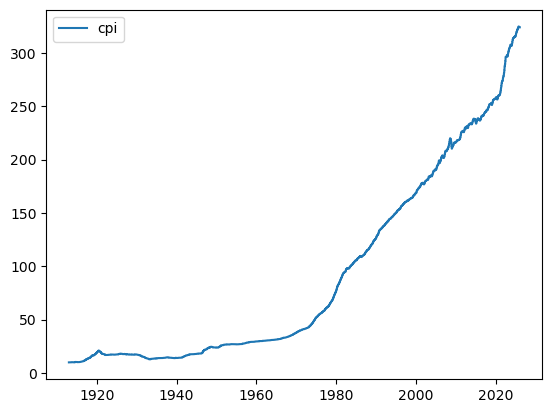

In [17]:
plot = sns.lineplot(data=cpi_daily)